In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import joblib

In [2]:
# Load Dataset
df = pd.read_csv(r"C:\Users\237229\Desktop\loan_amount_prediction_dataset_v2.csv")

In [3]:
# Basic Info
print(df.info())
print(df.describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 7 columns):
 #   Column                Non-Null Count  Dtype
---  ------                --------------  -----
 0   Age                   500 non-null    int64
 1   Monthly_Income        500 non-null    int64
 2   Credit_Score          500 non-null    int64
 3   Loan_Tenure_Years     500 non-null    int64
 4   Existing_Loan_Amount  500 non-null    int64
 5   Num_of_Dependents     500 non-null    int64
 6   Loan_Amount           500 non-null    int64
dtypes: int64(7)
memory usage: 27.5 KB
None
              Age  Monthly_Income  Credit_Score  Loan_Tenure_Years  \
count  500.000000      500.000000    500.000000          500.00000   
mean    40.416000    84094.666000    583.698000           14.76200   
std     11.345677    36555.333098    160.775646            8.23681   
min     21.000000    20422.000000    300.000000            1.00000   
25%     31.000000    51825.750000    445.750000            8.

In [4]:
# Check for missing values
print("Missing values:\n", df.isnull().sum())

Missing values:
 Age                     0
Monthly_Income          0
Credit_Score            0
Loan_Tenure_Years       0
Existing_Loan_Amount    0
Num_of_Dependents       0
Loan_Amount             0
dtype: int64


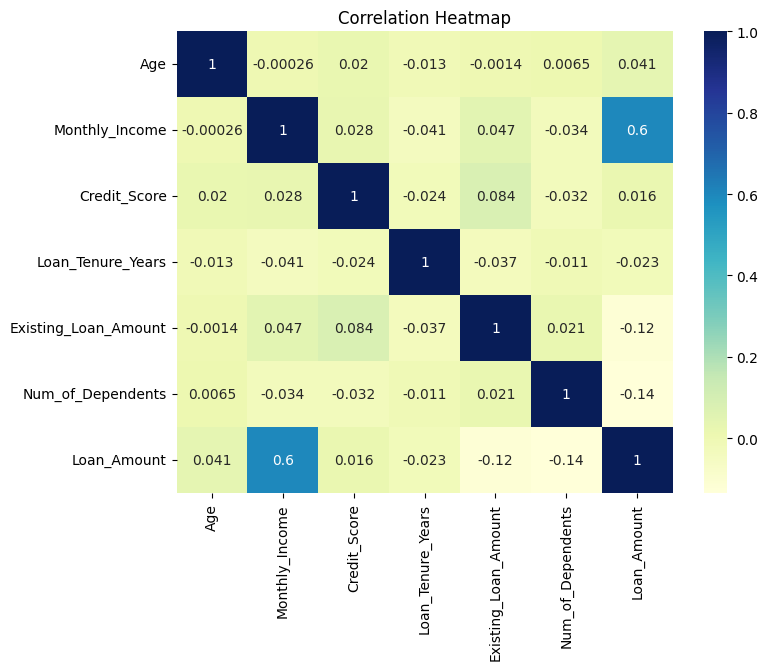

In [5]:
# Optional EDA
plt.figure(figsize=(8,6))
sns.heatmap(df.corr(), annot=True, cmap="YlGnBu")
plt.title("Correlation Heatmap")
plt.show()

In [6]:
# Features and Target
X = df[['Age', 'Monthly_Income', 'Credit_Score', 'Loan_Tenure_Years', 'Existing_Loan_Amount', 'Num_of_Dependents']]
y = df['Loan_Amount']

In [7]:
# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [8]:
# Train Linear Regression Model
model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [12]:
# Predictions and Evaluation
y_pred = model.predict(X_test)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("RMSE:", rmse)
print("R² Score:", r2)

RMSE: 16372.055700409157
R² Score: 0.29715025023167263


In [13]:
# Save the trained model
joblib.dump(model, "loan_model.pkl")
print("✅ Linear regression model saved as loan_model.pkl")

✅ Linear regression model saved as loan_model.pkl
